In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yusufmurtaza01/chest-xray-pneumonia-balanced-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.66G/1.66G [00:17<00:00, 103MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1


In [2]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
import matplotlib.image as mpimg
import random

In [ ]:
#Check folder structure.
for dirpath, dirnames, filenames in os.walk(path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 3 directories and 0 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1'.
There are 2 directories and 0 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val'.
There are 0 directories and 850 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val/PNEUMONIA'.
There are 0 directories and 850 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val/NORMAL'.
There are 2 directories and 0 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/test'.
There are 0 directories and 15 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/test/PNEUMONIA'.
There are 0 directories and 15 images in '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-ba

In [ ]:
#Function to verify random images
def view_random_image(target_dir, target_class):
  target_folder = os.path.join(target_dir, target_class)

  random_image = random.sample(os.listdir(target_folder), 1)

  img = mpimg.imread(os.path.join(target_folder, random_image[0]))
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  print(f"Image shape: {img.shape}")

  return img

In [ ]:
#Define folder paths
train_dir ='/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/train'
test_dir = '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/test'
val_data = '/root/.cache/kagglehub/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset/versions/1/val'

Displaying a random image from the 'PNEUMONIA' class:
Image shape: (824, 1136)


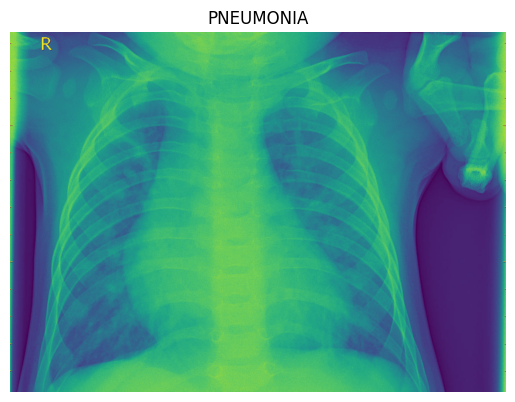

Displaying a random image from the 'NORMAL' class:
Image shape: (1979, 2517, 3)


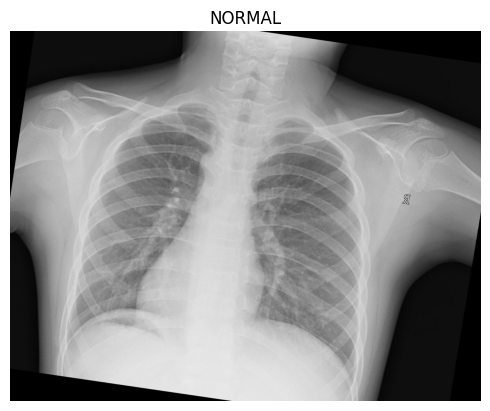

In [ ]:
#Verify a few random images.
train_dir = os.path.join(path, 'train')

class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in class_names:
    print(f"Displaying a random image from the '{class_name}' class:")
    img = view_random_image(train_dir, class_name)
    plt.show()

In [ ]:
#Gain insights about the image shape
img.shape

(1979, 2517, 3)

In [8]:
img/255.

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]])

In [9]:
import os

# Correctly define test_dir and val_data using the 'path' variable
test_dir = os.path.join(path, 'test')
val_data = os.path.join(path, 'val')

# Create a dataset for .jpeg files in each directory
train_dir_tf_jpeg = tf.data.Dataset.list_files(os.path.join(train_dir, "*", "*.jpeg"))
test_dir_tf_jpeg = tf.data.Dataset.list_files(os.path.join(test_dir, "*", "*.jpeg"))
val_data_tf_jpeg = tf.data.Dataset.list_files(os.path.join(val_data, "*", "*.jpeg"))

# Create a dataset for .jpg files in each directory
train_dir_tf_jpg = tf.data.Dataset.list_files(os.path.join(train_dir, "*", "*.jpg"))
test_dir_tf_jpg = tf.data.Dataset.list_files(os.path.join(test_dir, "*", "*.jpg"))
val_data_tf_jpg = tf.data.Dataset.list_files(os.path.join(val_data, "*", "*.jpg"))

# Concatenate the datasets for both extensions
train_dir_tf = train_dir_tf_jpeg.concatenate(train_dir_tf_jpg)
test_dir_tf = test_dir_tf_jpeg.concatenate(test_dir_tf_jpg)
val_data_tf = val_data_tf_jpeg.concatenate(val_data_tf_jpg)

In [ ]:
def edit_image(filepath):
  """
  This function resizes images to a uniform shape and normalizes pixel values.
  It expects the file path as input.
  """
  img = tf.io.read_file(filepath)
  img = tf.image.decode_jpeg(img, channels=1)

  img = tf.image.resize_with_pad(img, 224, 224)
  img = img/255.

  label_str = tf.strings.split(filepath, os.path.sep)[-2]

  label = tf.cast(label_str == 'PNEUMONIA', tf.int32)
  return img, label


train_dir_tf = train_dir_tf.map(edit_image)
test_dir_tf = test_dir_tf.map(edit_image)
val_data_tf = val_data_tf.map(edit_image)


In [11]:
for image, label in train_dir_tf.take(1):
    print("Image Shape:", image.shape)
    print("Label:", label.numpy())

Image Shape: (224, 224, 1)
Label: 1


In [ ]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

#Shuffle training set to prevent memorization, then batch and prefetch.
train_dataset = train_dir_tf.batch(BATCH_SIZE).prefetch(AUTOTUNE)

#Batching and prefetching is sufficient for test & val data
test_dataset = test_dir_tf.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_dataset = val_data_tf.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [13]:
from tensorflow.keras import layers, models

In [ ]:
#Function to plot training metrics.
def plot_history(history):
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Training and Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()



In [25]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-04-01 09:58:54--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-04-01 09:58:54 (128 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
#Inspect the resulting image matrix array.
from helper_functions import *

In [ ]:
# Augment data computationally to prevent previously failed model behaviors due to insufficient data variance.
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

# Create a data augmentation model
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

print("Data augmentation model created successfully.")

Data augmentation model created successfully.


In [ ]:
# Now that augmentation is ready, insert Batch Normalization after Conv2D layers and keep Dropout.
from tensorflow.keras.layers import BatchNormalization

model4 = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

model4.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Calculate Class Weights.
# NORMAL: 1341, PNEUMONIA: 3875, TOTAL: 5216
weight_for_0 = (1 / 1341) * (5216 / 2.0)
weight_for_1 = (1 / 3875) * (5216 / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

# Configure Training Callbacks
callbacks_list = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]
print("Class Weights and Callbacks Defined:", class_weights)

Class Weights and Callbacks Defined: {0: 1.9448173005219984, 1: 0.6730322580645162}


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 57s 213ms/step - accuracy: 0.7088 - loss: 0.7308 - recall: 0.4747 - val_accuracy: 0.5000 - val_loss: 20.8430 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 45s 208ms/step - accuracy: 0.6576 - loss: 0.9164 - recall: 0.3594 - val_accuracy: 0.5000 - val_loss: 19.3323 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 44s 208ms/step - accuracy: 0.6393 - loss: 1.0436 - recall: 0.3047 - val_accuracy: 0.5000 - val_loss: 31.6023 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - accuracy: 0.6096 - loss: 0.9050 - recall: 0.2388 - val_accuracy: 0.5000 - val_loss: 9.3038 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 43s 202ms/step - accuracy: 0.6129 - loss: 0.8654 - recall: 0.2529 - val_accuracy: 0.5000 - val_loss: 1.2791 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 6/30
2

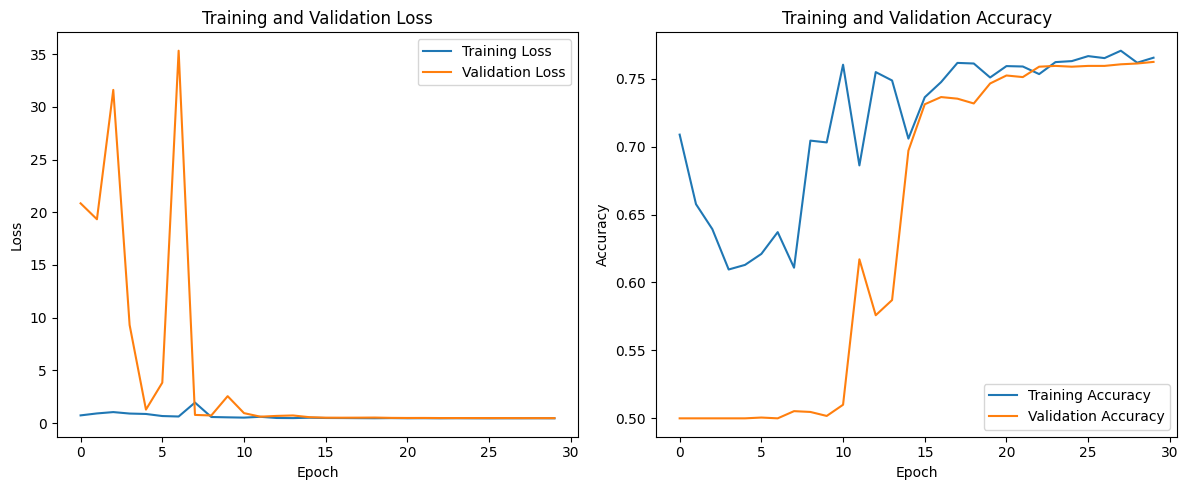

In [30]:
history4 = model4.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=callbacks_list,
)

plot_history(history=history4)

In [31]:
def edit_image_rgb(filepath):
  """
  Reads images as 3-channel (RGB), resizes, and normalizes them.
  """
  img = tf.io.read_file(filepath)
  # Switch to RGB format by setting channels=3
  img = tf.image.decode_jpeg(img, channels=3)

  img = tf.image.resize_with_pad(img, 224, 224)
  img = img / 255.

  label_str = tf.strings.split(filepath, os.path.sep)[-2]
  label = tf.cast(label_str == 'PNEUMONIA', tf.int32)
  return img, label

# Re-create datasets using the RGB load function
train_dataset_rgb = train_dir_tf_jpeg.concatenate(train_dir_tf_jpg).map(edit_image_rgb).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset_rgb = test_dir_tf_jpeg.concatenate(test_dir_tf_jpg).map(edit_image_rgb).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset_rgb = val_data_tf_jpeg.concatenate(val_data_tf_jpg).map(edit_image_rgb).batch(32).prefetch(tf.data.AUTOTUNE)

print("Datasets are successfully updated to RGB (3 channels).")

Datasets are successfully updated to RGB (3 channels).


In [32]:
from tensorflow.keras.layers import BatchNormalization, RandomFlip, RandomRotation, RandomZoom

# Model architecture adapted for RGB input (224, 224, 3)
model4_rgb = models.Sequential([
    # Data augmentation block
    RandomFlip('horizontal'),
    RandomRotation(0.2),
    RandomZoom(0.2),

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model4_rgb.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("RGB-supported model created and compiled. Ready for training.")

RGB-supported model created and compiled. Ready for training.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 65s 286ms/step - accuracy: 0.7737 - loss: 0.7614 - recall: 0.7579 - val_accuracy: 0.5000 - val_loss: 48.7687 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 60s 283ms/step - accuracy: 0.6960 - loss: 1.2367 - recall: 0.4371 - val_accuracy: 0.5041 - val_loss: 16.5270 - val_recall: 0.0082 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step - accuracy: 0.6854 - loss: 1.3157 - recall: 0.4082 - val_accuracy: 0.5476 - val_loss: 0.6870 - val_recall: 0.0953 - learning_rate: 2.0000e-04
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 70s 329ms/step - accuracy: 0.6787 - loss: 0.6235 - recall: 0.3850 - val_accuracy: 0.5018 - val_loss: 2.0590 - val_recall: 0.0035 - learning_rate: 2.0000e-04


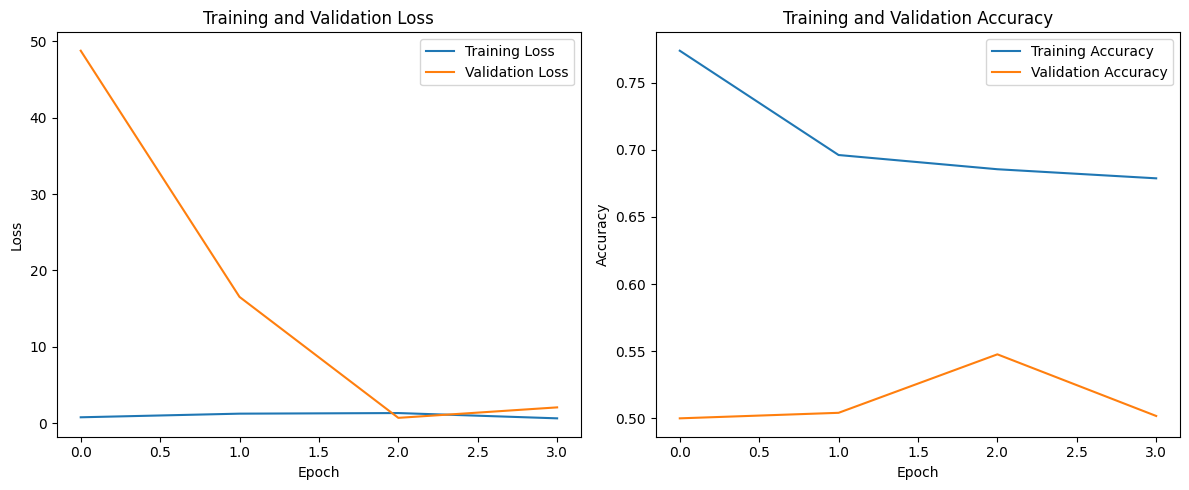

In [33]:
history_rgb = model4_rgb.fit(
    train_dataset_rgb,
    epochs=30,
    validation_data=val_dataset_rgb,
    class_weight=class_weights,
    callbacks=callbacks_list
)

# Visualize the training results
plot_history(history=history_rgb)

In [35]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Initialize ResNet50 as the base model using ImageNet weights
# Exclude the classification top layer to attach our custom dense head
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model weights for the initial training phase
base_model.trainable = False

# Architecture mapping single-channel input to 3-channel for ResNet compatibility
resnet_model = models.Sequential([
    layers.Input(shape=(224, 224, 1)),

    # Conv2D layer duplicating 1 channel into 3 channels
    layers.Conv2D(3, (3, 3), padding='same'),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,943 (90.48 MB)

 Trainable params: 131,231 (512.62 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 99s 320ms/step - accuracy: 0.7841 - loss: 0.4647 - recall: 0.9785 - val_accuracy: 0.5000 - val_loss: 3.3034 - val_recall: 0.0000e+00
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 51s 241ms/step - accuracy: 0.4446 - loss: 0.8789 - recall: 0.8126 - val_accuracy: 0.5000 - val_loss: 0.6932 - val_recall: 1.0000
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 50s 233ms/step - accuracy: 0.5000 - loss: 0.6960 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6932 - val_recall: 1.0000
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 83s 240ms/step - accuracy: 0.5000 - loss: 0.6956 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6932 - val_recall: 1.0000
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 50s 234ms/step - accuracy: 0.5000 - loss: 0.6955 - recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_recall: 1.0000
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 50s 233ms/step - accuracy: 0.4626 - loss: 0.6955 - recall: 0.8521 - val_accuracy: 0.5000 - val_loss: 0.6931 - v

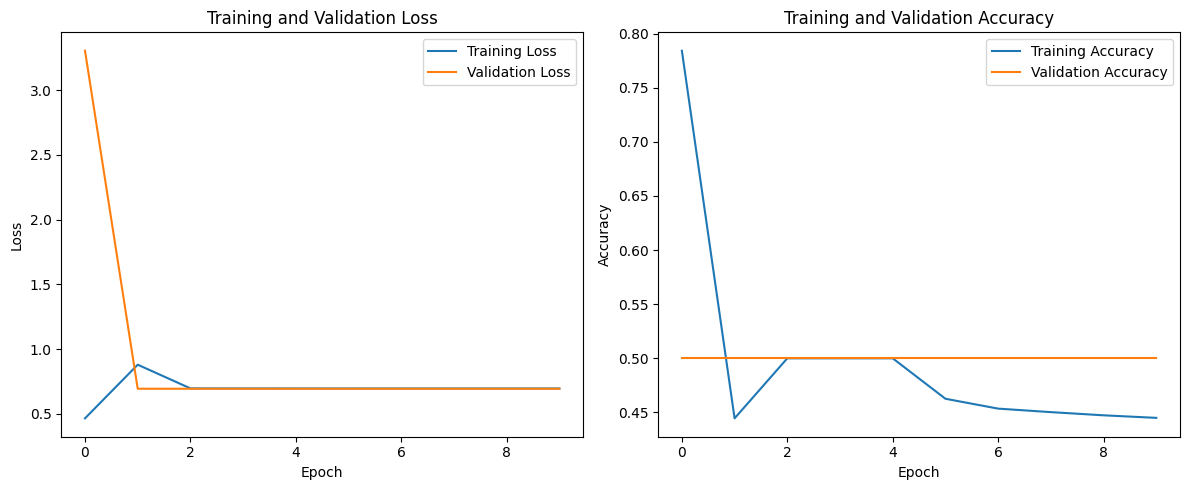

In [36]:
# Using our original single-channel datasets (train_dataset, val_dataset)
history_resnet = resnet_model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

plot_history(history=history_resnet)

In [37]:
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

print("ResNet50V2 model successfully loaded as 'base_model'.")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50V2 model successfully loaded as 'base_model'.


ResNet-based model created and compiled. Starting initial training.
Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 72s 298ms/step - accuracy: 0.9472 - loss: 0.1508 - recall: 0.9309 - val_accuracy: 0.5000 - val_loss: 3.1238 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 79s 285ms/step - accuracy: 0.9435 - loss: 0.1661 - recall: 0.9159 - val_accuracy: 0.5124 - val_loss: 2.5343 - val_recall: 0.0247 - learning_rate: 0.0010
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 290ms/step - accuracy: 0.9131 - loss: 0.2410 - recall: 0.8544 - val_accuracy: 0.8094 - val_loss: 0.6430 - val_recall: 0.6200 - learning_rate: 2.0000e-04
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.9466 - loss: 0.1374 - recall: 0.9168 - val_accuracy: 0.8118 - val_loss: 0.6476 - val_recall: 0.6247 - learning_rate: 2.0000e-04


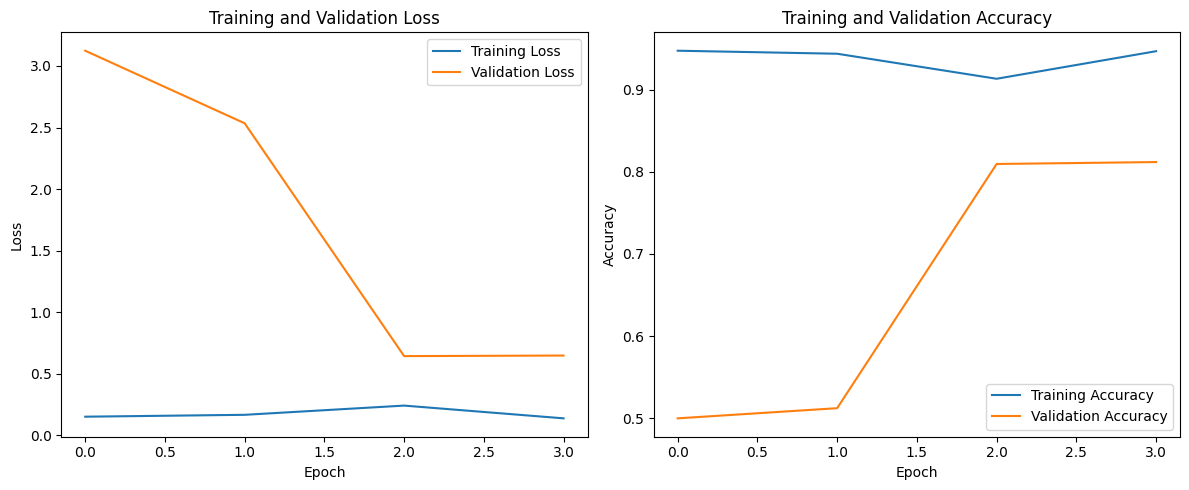

Model layers unfrozen and re-compiled with a low learning rate.
Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 145s 522ms/step - accuracy: 0.8774 - loss: 0.2796 - recall: 0.7685 - val_accuracy: 0.7253 - val_loss: 0.6039 - val_recall: 0.4600 - learning_rate: 1.0000e-05
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 147s 547ms/step - accuracy: 0.9532 - loss: 0.1414 - recall: 0.9312 - val_accuracy: 0.5865 - val_loss: 1.1156 - val_recall: 0.1729 - learning_rate: 1.0000e-05
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 132s 621ms/step - accuracy: 0.9274 - loss: 0.1835 - recall: 0.8700 - val_accuracy: 0.9000 - val_loss: 0.2415 - val_recall: 0.8071 - learning_rate: 2.0000e-06
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 128s 553ms/step - accuracy: 0.9651 - loss: 0.1074 - recall: 0.9482 - val_accuracy: 0.9147 - val_loss: 0.2104 - val_recall: 0.8412 - learning_rate: 2.0000e-06
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 117s 547ms/step - accuracy: 0.9699 - loss: 0.0947 - recall: 0.9562 - val_accuracy: 0.9112 - val_loss: 0.

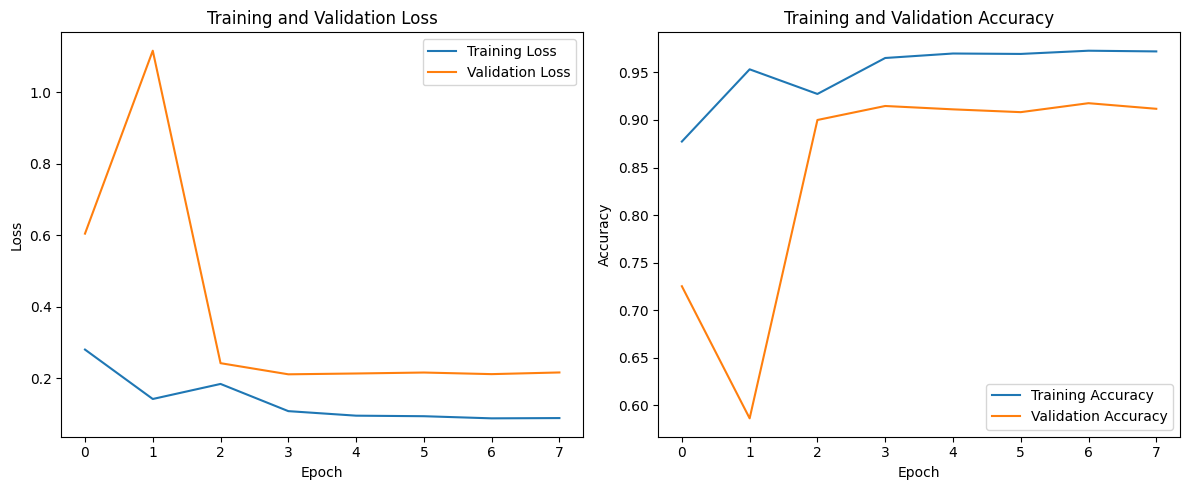

In [40]:
# Freeze the base model for initial feature extraction
base_model.trainable = False

# Construct the sequential ResNet model
resnet_model = models.Sequential([
    data_augmentation, # Data augmentation block
    base_model,        # Pre-trained ResNet50V2 base model
    layers.GlobalAveragePooling2D(), # Global Average Pooling to summarize feature maps
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Sigmoid activation for binary classification
])

# Compile the model
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("ResNet-based model created and compiled. Starting initial training.")

# Train the model
history_resnet = resnet_model.fit(
    train_dataset_rgb, # Using RGB datasets
    epochs=30,
    validation_data=val_dataset_rgb, # Using RGB datasets
    class_weight=class_weights,
    callbacks=callbacks_list
)

# Plot the results
plot_history(history=history_resnet)

# Unfreeze the base model for fine-tuning
base_model.trainable = True

# Re-compile the model with a very low learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low learning rate for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

print("Model layers unfrozen and re-compiled with a low learning rate.")

# Re-train the un-frozen model (Fine-tuning)
history_finetune = resnet_model.fit(
    train_dataset_rgb, # Using RGB datasets
    epochs=30, # Train for more epochs during fine-tuning
    validation_data=val_dataset_rgb, # Using RGB datasets
    class_weight=class_weights,
    callbacks=callbacks_list
)

# Plot the results
plot_history(history=history_finetune)

In [41]:
# Due to EarlyStopping's restore_best_weights=True, the model currently holds the best weights.
# Let's explicitly save the final model to disk:
resnet_model.save('best_model.keras')
print('The most successful model has been saved as 'best_model.keras'.')

The most successful model has been saved as 'best_model.keras'.
